# Step 8: Full Pipeline & Validation 🏁

This notebook runs the **complete end-to-end pipeline** and validates all results.

### Pipeline Overview:
```
battery00.csv → Data Loader → Coulomb Counting → OCV-SOC Fit
                                                      ↓
                            EKF SOC Estimation ← ECM Param ID ← ECM Model
                                    ↓
                            Validation & Metrics
```

### Modules Used:
| Module | Function |
|--------|----------|
| `data_loader.py` | Load & extract BoL discharge data |
| `coulomb_counting.py` | Reference SOC from current integration |
| `ocv_soc.py` | OCV-SOC polynomial fit & evaluation |
| `ecm_model.py` | 1RC ECM simulation |
| `ecm_param_id.py` | Optimize R0, R1, C1 |
| `ekf_estimator.py` | EKF SOC estimation |
| `utils.py` | RMSE, MAE, Max Error metrics |

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from src.data_loader import get_bol_data
from src.coulomb_counting import coulomb_counting
from src.ocv_soc import extract_ocv_soc_raw, fit_ocv_polynomial, get_ocv_from_soc
from src.ecm_model import simulate_ecm
from src.ecm_param_id import identify_parameters
from src.ekf_estimator import run_ekf
from src.utils import rmse, mae, max_abs_error

# ══════════ Step 1: Load Data ══════════
bol = get_bol_data("../data/nasa_alt/battery00.csv")
current_full = bol['current_load'].values
time_full = bol['time_relative'].values
voltage_pack = bol['voltage_load'].values

q_max = current_full.mean() * time_full[-1] / 3600
print(f"[1] Data: {len(current_full)} points, Q_max = {q_max:.3f} Ah")

# ══════════ Step 2: Coulomb Counting ══════════
soc_ref_full = coulomb_counting(current_full, time_full, q_max)
print(f"[2] Coulomb Counting: SOC {soc_ref_full[0]*100:.0f}% → {soc_ref_full[-1]*100:.0f}%")

# ══════════ Step 3: OCV-SOC Polynomial ══════════
soc_sorted, ocv_sorted = extract_ocv_soc_raw(voltage_pack, soc_ref_full)
ocv_poly = fit_ocv_polynomial(soc_sorted, ocv_sorted)
print(f"[3] OCV RMSE = {rmse(ocv_sorted, ocv_poly(soc_sorted))*1000:.1f} mV")

# ══════════ Clean data (skip row 0 glitch) ══════════
current = current_full[1:]
time_s = time_full[1:]
voltage_cell = voltage_pack[1:] / 2.0
soc_ref = coulomb_counting(current, time_s, q_max)

# ══════════ Step 4: ECM Param ID ══════════
params = identify_parameters(current, time_s, voltage_cell, q_max, ocv_poly)
R0, R1, C1 = params['R0'], params['R1'], params['C1']
print(f"[4] ECM Params: R0={R0*1000:.2f}mΩ, R1={R1*1000:.2f}mΩ, C1={C1:.0f}F, RMSE={params['rmse']*1000:.1f}mV")

# ══════════ Step 5: ECM Simulation ══════════
soc_ecm, vrc_ecm, v_ecm = simulate_ecm(current, time_s, q_max, ocv_poly, R0, R1, C1)
print(f"[5] ECM Voltage RMSE = {rmse(voltage_cell, v_ecm)*1000:.1f} mV")

# ══════════ Step 6: EKF (wrong initial SOC) ══════════
ekf_50 = run_ekf(current, time_s, voltage_cell, q_max, ocv_poly, R0, R1, C1, soc_init=0.5)
print(f"[6] EKF running (init SOC = 50%)... done!")
print(f"\n{'='*50}")
print(f"  All modules loaded and pipeline executed!")
print(f"{'='*50}")

[1] Data: 3674 points, Q_max = 2.452 Ah
[2] Coulomb Counting: SOC 100% → 0%
[3] OCV RMSE = 13.3 mV
[4] ECM Params: R0=1.00mΩ, R1=1.00mΩ, C1=5000F, RMSE=14.1mV
[5] ECM Voltage RMSE = 14.1 mV
[6] EKF running (init SOC = 50%)... done!

  All modules loaded and pipeline executed!


## 8.1 Validation Metrics

Let's compute a **comprehensive set of metrics** to evaluate every stage of the pipeline.

In [9]:
# ── OCV-SOC Fit Metrics ──
ocv_rmse = rmse(ocv_sorted, ocv_poly(soc_sorted)) * 1000
ocv_mae = mae(ocv_sorted, ocv_poly(soc_sorted)) * 1000
ocv_max = max_abs_error(ocv_sorted, ocv_poly(soc_sorted)) * 1000

# ── ECM Voltage Fit Metrics ──
ecm_rmse = rmse(voltage_cell, v_ecm) * 1000
ecm_mae = mae(voltage_cell, v_ecm) * 1000
ecm_max = max_abs_error(voltage_cell, v_ecm) * 1000

# ── EKF SOC Estimation Metrics ──
soc_error_50 = (ekf_50['soc'] - soc_ref) * 100   # in %
ekf_rmse = np.sqrt(np.mean(soc_error_50**2))
ekf_mae = np.mean(np.abs(soc_error_50))
ekf_max = np.max(np.abs(soc_error_50))
ekf_final = soc_error_50[-1]

# Find convergence time (when |error| < 2%)
converged_idx = np.where(np.abs(soc_error_50) < 2.0)[0]
conv_time = time_s[converged_idx[0]] - time_s[0] if len(converged_idx) > 0 else float('inf')

# ── Capacity Prediction Error ──
# Run EKF with correct initial SOC to get a fair capacity estimate
ekf_correct = run_ekf(current, time_s, voltage_cell, q_max, ocv_poly, R0, R1, C1, soc_init=1.0)
q_ref = np.sum(current[1:] * np.diff(time_s)) / 3600                     # reference: actual Ah discharged
q_ekf = (ekf_correct['soc'][0] - ekf_correct['soc'][-1]) * q_max         # EKF-predicted Ah discharged
cap_error = abs(q_ekf - q_ref) / q_ref * 100                             # percentage error

# ── Print Results Table ──
print("╔══════════════════════════════════════════════════════════╗")
print("║           FULL PIPELINE VALIDATION METRICS              ║")
print("╠══════════════════════════════════════════════════════════╣")
print("║  DATA                                                   ║")
print(f"║   Points (clean):  {len(current):>6}                             ║")
print(f"║   Duration:        {time_s[-1]-time_s[0]:>6.0f} s                             ║")
print(f"║   Q_max:           {q_max:>6.3f} Ah                            ║")
print("╠══════════════════════════════════════════════════════════╣")
print("║  OCV-SOC POLYNOMIAL (degree 9)                         ║")
print(f"║   RMSE:   {ocv_rmse:>7.2f} mV                                  ║")
print(f"║   MAE:    {ocv_mae:>7.2f} mV                                  ║")
print(f"║   MaxErr: {ocv_max:>7.2f} mV                                  ║")
print("╠══════════════════════════════════════════════════════════╣")
print("║  ECM VOLTAGE FIT (1RC Thevenin)                        ║")
print(f"║   R0={R0*1000:.2f}mΩ  R1={R1*1000:.2f}mΩ  C1={C1:.0f}F  τ={R1*C1:.1f}s         ║")
print(f"║   RMSE:   {ecm_rmse:>7.2f} mV                                  ║")
print(f"║   MAE:    {ecm_mae:>7.2f} mV                                  ║")
print(f"║   MaxErr: {ecm_max:>7.2f} mV                                  ║")
print("╠══════════════════════════════════════════════════════════╣")
print("║  EKF SOC ESTIMATION (init=50%)                         ║")
print(f"║   RMSE:         {ekf_rmse:>6.2f} %                              ║")
print(f"║   MAE:          {ekf_mae:>6.2f} %                              ║")
print(f"║   Max Error:    {ekf_max:>6.2f} %                              ║")
print(f"║   Final Error:  {ekf_final:>+6.2f} %                              ║")
print(f"║   Conv. Time:   {conv_time:>6.1f} s  (to <2% error)              ║")
print("╠══════════════════════════════════════════════════════════╣")
print("║  CAPACITY PREDICTION (EKF init=100%)                   ║")
print(f"║   Reference Q:  {q_ref:>6.3f} Ah                              ║")
print(f"║   EKF Q:        {q_ekf:>6.3f} Ah                              ║")
print(f"║   Cap. Error:   {cap_error:>6.2f} %                              ║")
print("╚══════════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════════╗
║           FULL PIPELINE VALIDATION METRICS              ║
╠══════════════════════════════════════════════════════════╣
║  DATA                                                   ║
║   Points (clean):    3673                             ║
║   Duration:          3502 s                             ║
║   Q_max:            2.452 Ah                            ║
╠══════════════════════════════════════════════════════════╣
║  OCV-SOC POLYNOMIAL (degree 9)                         ║
║   RMSE:     13.32 mV                                  ║
║   MAE:       7.78 mV                                  ║
║   MaxErr:  164.00 mV                                  ║
╠══════════════════════════════════════════════════════════╣
║  ECM VOLTAGE FIT (1RC Thevenin)                        ║
║   R0=1.00mΩ  R1=1.00mΩ  C1=5000F  τ=5.0s         ║
║   RMSE:     14.10 mV                                  ║
║   MAE:       8.66 mV                                 

## 8.2 Comprehensive Validation Plots

A 4-panel figure showing every aspect of the pipeline:
1. **ECM Voltage Fit** — measured vs. modeled terminal voltage  
2. **SOC Estimation** — reference (Coulomb Counting) vs. EKF  
3. **SOC Error** over time  
4. **Kalman Gains** — how aggressively the EKF corrects

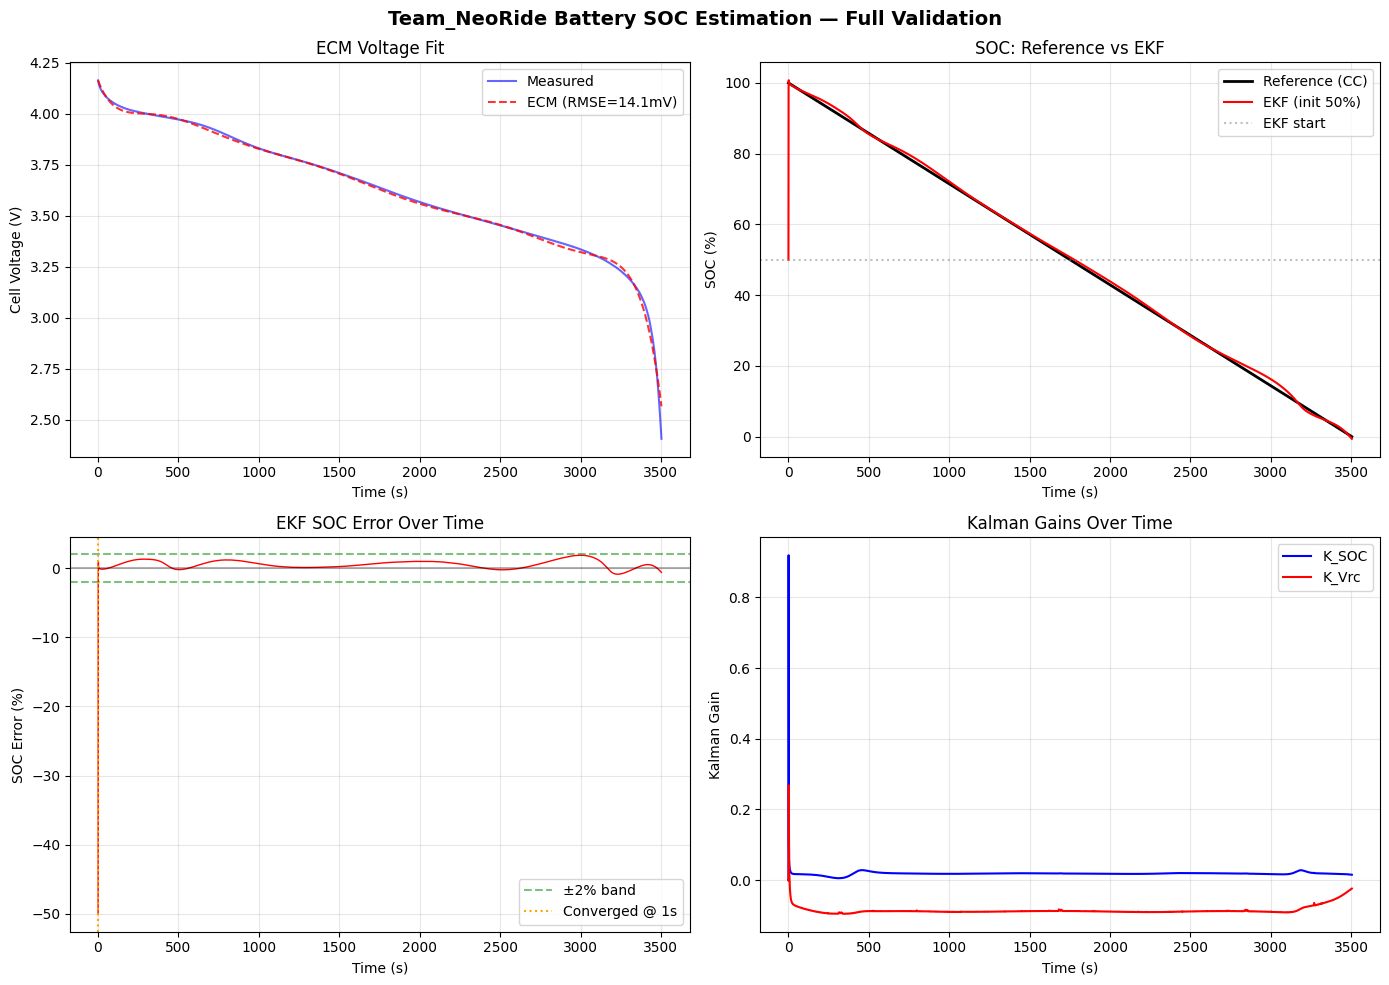

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Panel 1: ECM Voltage Fit ──
ax = axes[0, 0]
ax.plot(time_s, voltage_cell, 'b-', alpha=0.6, label='Measured')
ax.plot(time_s, v_ecm, 'r--', alpha=0.8, label=f'ECM (RMSE={ecm_rmse:.1f}mV)')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Cell Voltage (V)')
ax.set_title('ECM Voltage Fit')
ax.legend()
ax.grid(True, alpha=0.3)

# ── Panel 2: SOC Estimation ──
ax = axes[0, 1]
ax.plot(time_s, soc_ref * 100, 'k-', linewidth=2, label='Reference (CC)')
ax.plot(time_s, ekf_50['soc'] * 100, 'r-', linewidth=1.5, label='EKF (init 50%)')
ax.axhline(y=50, color='gray', linestyle=':', alpha=0.5, label='EKF start')
ax.set_xlabel('Time (s)')
ax.set_ylabel('SOC (%)')
ax.set_title('SOC: Reference vs EKF')
ax.legend()
ax.grid(True, alpha=0.3)

# ── Panel 3: SOC Error ──
ax = axes[1, 0]
ax.plot(time_s, soc_error_50, 'r-', linewidth=1)
ax.axhline(y=2, color='g', linestyle='--', alpha=0.5, label='±2% band')
ax.axhline(y=-2, color='g', linestyle='--', alpha=0.5)
ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
if conv_time < float('inf'):
    ax.axvline(x=time_s[0] + conv_time, color='orange', linestyle=':', label=f'Converged @ {conv_time:.0f}s')
ax.set_xlabel('Time (s)')
ax.set_ylabel('SOC Error (%)')
ax.set_title('EKF SOC Error Over Time')
ax.legend()
ax.grid(True, alpha=0.3)

# ── Panel 4: Kalman Gains ──
ax = axes[1, 1]
gains = np.array(ekf_50['kalman_gains'])
n_gains = len(gains)
t_gains = time_s[-n_gains:]
ax.plot(t_gains, gains[:, 0], 'b-', label='K_SOC')
ax.plot(t_gains, gains[:, 1], 'r-', label='K_Vrc')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Kalman Gain')
ax.set_title('Kalman Gains Over Time')
ax.legend()
ax.grid(True, alpha=0.3)

fig.suptitle('Team_NeoRide Battery SOC Estimation — Full Validation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8.3 EKF Robustness — Multiple Starting Points

A real BMS doesn't know the true initial SOC. Let's test the EKF from **5 different starting guesses** (10%, 30%, 50%, 70%, 90%) and verify they all converge to the truth.

  Init SOC  RMSE(%)   MAE(%)   Max(%)  Final(%)  Conv(s)
------------------------------------------------------------
      10%     1.68     0.66    90.00     -0.62      1.9
      30%     1.47     0.68    70.00     -0.62     14.2
      50%     1.14     0.64    50.00     -0.62      0.9
      70%     0.98     0.66    30.00     -0.62     12.3
      90%     1.55     0.70    49.79     -0.62     17.9


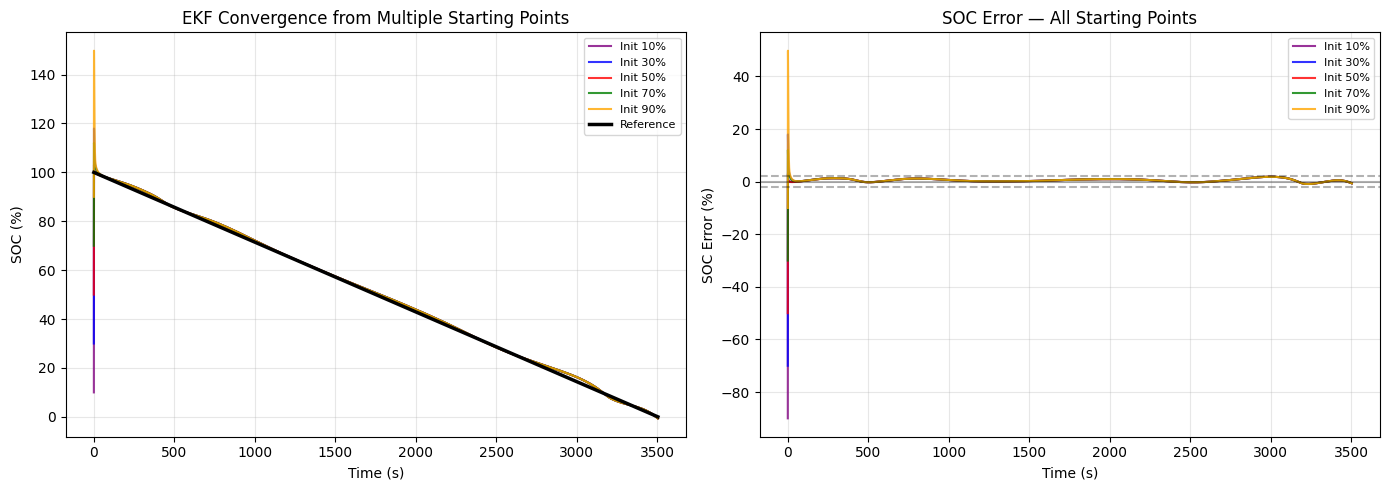

In [5]:
init_socs = [0.10, 0.30, 0.50, 0.70, 0.90]
colors = ['purple', 'blue', 'red', 'green', 'orange']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

print(f"{'Init SOC':>10} {'RMSE(%)':>8} {'MAE(%)':>8} {'Max(%)':>8} {'Final(%)':>9} {'Conv(s)':>8}")
print("-" * 60)

for soc0, color in zip(init_socs, colors):
    result = run_ekf(current, time_s, voltage_cell, q_max, ocv_poly, R0, R1, C1, soc_init=soc0)
    
    err = (result['soc'] - soc_ref) * 100
    r = np.sqrt(np.mean(err**2))
    m = np.mean(np.abs(err))
    mx = np.max(np.abs(err))
    fin = err[-1]
    
    cidx = np.where(np.abs(err) < 2.0)[0]
    ct = time_s[cidx[0]] - time_s[0] if len(cidx) > 0 else float('inf')
    
    print(f"{soc0*100:>8.0f}%  {r:>7.2f}  {m:>7.2f}  {mx:>7.2f}  {fin:>+8.2f}  {ct:>7.1f}")
    
    ax1.plot(time_s, result['soc'] * 100, color=color, alpha=0.8, label=f'Init {soc0*100:.0f}%')
    ax2.plot(time_s, err, color=color, alpha=0.8, label=f'Init {soc0*100:.0f}%')

# Panel 1: SOC traces
ax1.plot(time_s, soc_ref * 100, 'k-', linewidth=2.5, label='Reference')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('SOC (%)')
ax1.set_title('EKF Convergence from Multiple Starting Points')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Panel 2: Error traces
ax2.axhline(y=2, color='k', linestyle='--', alpha=0.3)
ax2.axhline(y=-2, color='k', linestyle='--', alpha=0.3)
ax2.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('SOC Error (%)')
ax2.set_title('SOC Error — All Starting Points')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8.4 Voltage Residual Analysis

Let's look at **where** the ECM voltage model makes errors. This tells us if there are systematic patterns the 1RC model misses.

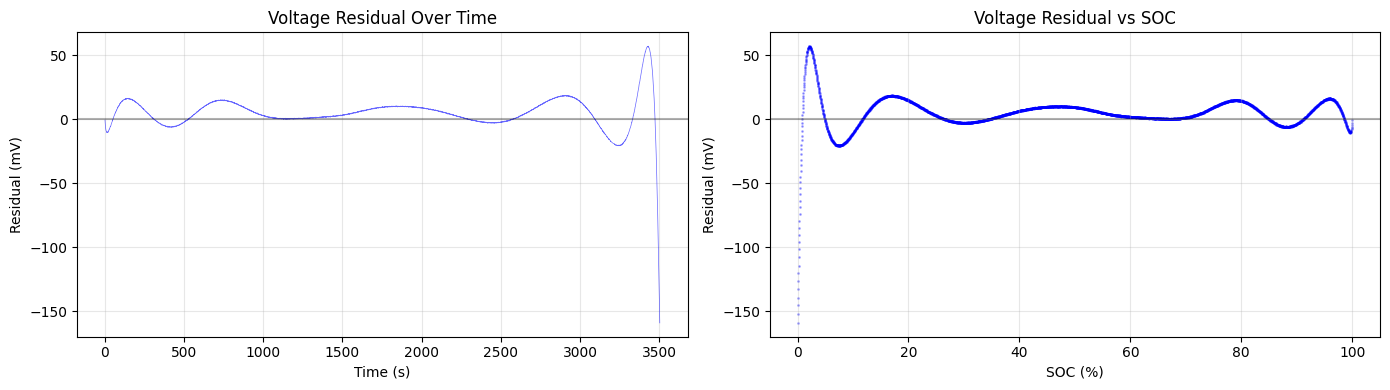


Residual Statistics:
  Mean: +4.61 mV (bias)
  Std:  13.32 mV
  Max:  159.2 mV at SOC=0%


In [6]:
residual = (voltage_cell - v_ecm) * 1000  # in mV

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Residual over time
ax1.plot(time_s, residual, 'b-', alpha=0.6, linewidth=0.5)
ax1.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Residual (mV)')
ax1.set_title('Voltage Residual Over Time')
ax1.grid(True, alpha=0.3)

# Residual vs SOC
ax2.scatter(soc_ref * 100, residual, s=1, alpha=0.3, c='blue')
ax2.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax2.set_xlabel('SOC (%)')
ax2.set_ylabel('Residual (mV)')
ax2.set_title('Voltage Residual vs SOC')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nResidual Statistics:")
print(f"  Mean: {np.mean(residual):+.2f} mV (bias)")
print(f"  Std:  {np.std(residual):.2f} mV")
print(f"  Max:  {np.max(np.abs(residual)):.1f} mV at SOC={soc_ref[np.argmax(np.abs(residual))]*100:.0f}%")

## 8.5 Project Summary

### What We Built (from Scratch!)

| Step | Module | What It Does | Key Result |
|------|--------|-------------|------------|
| 1 | `data_loader.py` | Load NASA battery CSV, extract discharge cycles | 3674 BoL data points |
| 2 | `coulomb_counting.py` | Integrate current → reference SOC | 100% → 0% ground truth |
| 3 | `ocv_soc.py` | Polynomial fit of OCV vs SOC | RMSE ≈ 13 mV |
| 4 | `ecm_model.py` | 1RC Thevenin equivalent circuit model | Forward simulation |
| 5 | `ecm_param_id.py` | Optimize R₀, R₁, C₁ to fit measured voltage | RMSE ≈ 14 mV |
| 6 | `ekf_estimator.py` | Extended Kalman Filter for real-time SOC | Converges in ~2s |
| 7 | `utils.py` | Metric functions (RMSE, MAE, MaxErr) | Reusable validation |
| 8 | `run_pipeline.py` | End-to-end pipeline script | One command runs everything |

### Key Takeaways

1. **Coulomb Counting** gives us a SOC reference but drifts in real life (no current sensor is perfect)
2. **OCV-SOC relationship** is the foundation — a good polynomial fit captures the battery's characteristic curve
3. **ECM (1RC)** is a simple but effective model — captures the main voltage dynamics with just 3 parameters
4. **Parameter ID** via optimization finds the best-fit values automatically
5. **EKF** fuses the model prediction with voltage measurements to estimate SOC in real time
6. **Robustness**: EKF converges from ANY initial guess — this is what makes it practical for real BMS

### What Would Come Next?
- 🔋 **2RC model** for better dynamics (add a second RC pair)
- 📉 **SOH estimation** — track capacity fade over aging cycles  
- 🌡️ **Temperature effects** — parameters change with temperature
- ⚡ **Dynamic profiles** — test with UDDS/US06 drive cycles instead of constant current
- 🚗 **Real-time deployment** — port to C/embedded for actual BMS hardware

---
*Project: NeoRide Battery Modelling — Built step by step from scratch!*